# Preprocesamiento y Exploración de Datos

Este notebook actúa como orquestador visual para el script modular `preprocesamiento.py`. Aquí cargamos el dataset crudo, ejecutamos las transformaciones (limpieza, lags temporales, promedios móviles, integración climática y codificación) y exploramos los resultados finales listos para el modelo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos tu pipeline modular
from preprocesamiento import preprocesar_datos, obtener_resumen

import warnings
warnings.filterwarnings('ignore')

## 1. Carga del Dataset Crudo

In [2]:
CSV_CRUDO_PATH = 'data/processed/dataset_crudo_sipa.csv'

df_crudo = pd.read_csv(CSV_CRUDO_PATH)

print(f"Registros originales extraídos: {len(df_crudo)}")
display(df_crudo.head())

Registros originales extraídos: 55430


,Año,Mes,Tipo Mercado,Mercado,Provincia,Cantón,producto_raw,Pres.,Cant.,Unidad Medida,...,provincia,mercado,canton,presentacion,tipo_mercado,precio_anterior,variacion,periodo,estado_precio,categoria
0,2012,Enero,Mayorista,Cuenca - EL ARENAL,Azuay,Cuenca,Aguacate Fuerte,Ciento,55.0,Libra,...,AZUAY,Cuenca - EL ARENAL,Cuenca,Ciento,Mayorista,NaN,NaN,2012-01,parcial,perecedero
1,2012,Febrero,Mayorista,Cuenca - EL ARENAL,Azuay,Cuenca,Aguacate Fuerte,Ciento,55.0,Libra,...,AZUAY,Cuenca - EL ARENAL,Cuenca,Ciento,Mayorista,28.500000,7.017544,2012-02,completo,perecedero
2,2012,Marzo,Mayorista,Cuenca - EL ARENAL,Azuay,Cuenca,Aguacate Fuerte,Ciento,55.0,Libra,...,AZUAY,Cuenca - EL ARENAL,Cuenca,Ciento,Mayorista,30.500000,28.961749,2012-03,completo,perecedero
3,2012,Abril,Mayorista,Cuenca - EL ARENAL,Azuay,Cuenca,Aguacate Fuerte,Ciento,55.0,Libra,...,AZUAY,Cuenca - EL ARENAL,Cuenca,Ciento,Mayorista,39.333333,1.694915,2012-04,completo,perecedero
4,2012,Mayo,Mayorista,Cuenca - EL ARENAL,Azuay,Cuenca,Aguacate Fuerte,Ciento,55.0,Libra,...,AZUAY,Cuenca - EL ARENAL,Cuenca,Ciento,Mayorista,40.000000,-10.000000,2012-05,completo,perecedero


## 2. Ejecución del Pipeline Modular

El script `preprocesamiento.py` se encargará de:
1. Limpiar strings y unificar productos canónicos.
2. Pivotar la tabla para rellenar vacíos históricos (Interpolación lineal + ffill/bfill).
3. Generar variables continuas (Promedios móviles, Volatilidad, Momentum, Interacciones).
4. Hacer un lookup del clima histórico en base a la provincia, año y mes.
5. Codificar las variables categóricas (Target Encoding).

In [3]:
print("Ejecutando transformaciones estructurales y feature engineering...")
resultado_preproc = preprocesar_datos(df_crudo)

df_preprocesado = resultado_preproc['dataset_final']
estadisticas = resultado_preproc['estadisticas']

print("\n=== RESUMEN DE TRANSFORMACIÓN ===")
for k, v in estadisticas.items():
    if k not in ['lista_descartados', 'columnas_modelo']:
        print(f"{k.replace('_', ' ').capitalize()}: {v}")

if estadisticas['productos_descartados'] > 0:
    print("\n[!] Se descartaron productos por tener demasiados vacíos históricos.")

Ejecutando transformaciones estructurales y feature engineering...

=== RESUMEN DE TRANSFORMACIÓN ===
Registros originales: 55430
Productos originales: 121
Provincias: 17
Registros completos: 54033
Registros parciales: 1397
Registros invalidos: 0
Registros despues filtro: 294
Productos descartados: 1263
Registros modelo: 50862

[!] Se descartaron productos por tener demasiados vacíos históricos.


## 3. Análisis de la Variable Objetivo (`comportamiento`)

Distribución de clases generada en base a los umbrales dinámicos de variación:


,Cantidad,Porcentaje (%)
comportamiento,,
Estable,32519,63.9
Alza,9335,18.4
Caída,9008,17.7


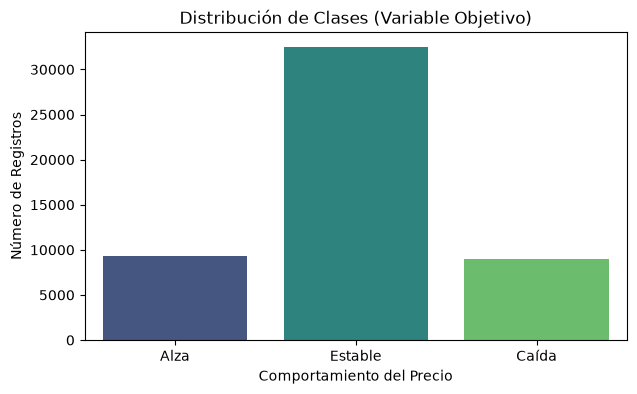

In [4]:
conteo = df_preprocesado['comportamiento'].value_counts()
porcentajes = df_preprocesado['comportamiento'].value_counts(normalize=True).round(3) * 100

resumen_target = pd.DataFrame({
    'Cantidad': conteo, 
    'Porcentaje (%)': porcentajes
})

print("Distribución de clases generada en base a los umbrales dinámicos de variación:")
display(resumen_target)

# Gráfica de distribución
plt.figure(figsize=(7, 4))
sns.countplot(data=df_preprocesado, x='comportamiento', order=['Alza', 'Estable', 'Caída'], palette='viridis')
plt.title('Distribución de Clases (Variable Objetivo)')
plt.ylabel('Número de Registros')
plt.xlabel('Comportamiento del Precio')
plt.show()

## 4. Revisión Final del Dataset

Verificamos las dimensiones y previsualizamos cómo entra la data a la red neuronal y modelos de ensamble.

In [5]:
print(f"Dimensiones finales del dataset: {df_preprocesado.shape}\n")

print("Columnas climáticas y temporales inyectadas:")
cols_especiales = [c for c in df_preprocesado.columns if 'clima' in c or 'var_' in c or 'promedio_' in c]
print(cols_especiales)

display(df_preprocesado.head())

Dimensiones finales del dataset: (50862, 42)

Columnas climáticas y temporales inyectadas:
['promedio_movil_2q', 'promedio_movil_3q', 'clima_temp_media', 'clima_precipitacion_mm', 'clima_temp_lag1', 'clima_temp_lag2', 'clima_precip_lag1', 'clima_precip_lag2', 'clima_precip_acc3']


,producto,provincia,canton,mercado,presentacion,tipo_mercado,periodo,precio_actual,precio_t1,precio_t2,...,variacion_real,comportamiento,categoria,producto_encoded,provincia_encoded,canton_encoded,mercado_encoded,presentacion_encoded,tipo_mercado_encoded,categoria_perecedero
0,Aguacate Fuerte,AZUAY,Cuenca,Cuenca - EL ARENAL,Ciento,Mayorista,2012-02,30.500000,28.500000,NaN,...,7.02,Alza,perecedero,0.617002,0.763943,0.763943,0.820395,0.693245,1.015672,1
1,Aguacate Fuerte,AZUAY,Cuenca,Cuenca - EL ARENAL,Ciento,Mayorista,2012-03,39.333333,30.500000,28.500000,...,28.96,Alza,perecedero,0.617002,0.763943,0.763943,0.820395,0.693245,1.015672,1
2,Aguacate Fuerte,AZUAY,Cuenca,Cuenca - EL ARENAL,Ciento,Mayorista,2012-04,40.000000,39.333333,30.500000,...,1.69,Estable,perecedero,0.617002,0.763943,0.763943,0.820395,0.693245,1.015672,1
3,Aguacate Fuerte,AZUAY,Cuenca,Cuenca - EL ARENAL,Ciento,Mayorista,2012-05,36.000000,40.000000,39.333333,...,-10.00,Caída,perecedero,0.617002,0.763943,0.763943,0.820395,0.693245,1.015672,1
4,Aguacate Fuerte,AZUAY,Cuenca,Cuenca - EL ARENAL,Ciento,Mayorista,2012-06,35.571429,36.000000,40.000000,...,-1.19,Estable,perecedero,0.617002,0.763943,0.763943,0.820395,0.693245,1.015672,1
